# Data Analysis: AI Model Risk Validation Case Studies

This notebook applies and compares two machine learning models, **XGBoost** and **Logistic Regression**, across two datasets representing AI use cases relevant to Model Risk Management:

1. **LendingClub Loan Data** — predicting loan default risk (`not.fully.paid`)
2. **UCI Adult Census Income** — predicting income classification (`>$50K`)

Each dataset is treated as an independent case study, reflecting how a Model Risk Management analyst would validate different AI use cases deployed across a firm.

## Part A: LendingClub Loan Default Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

pd.set_option('display.max_columns', None)

## 1. Load and Inspect the Data

In [3]:
df = pd.read_csv('loan_data.csv')
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [4]:
print("Shape:", df.shape)
df.info()

Shape: (9578, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


## 2. Exploratory Data Analysis

### 2.1 Target Variable Balance
The target variable `not.fully.paid` indicates whether a borrower defaulted (1) or fully repaid (0). Checking class balance is essential, as imbalanced classes affect model evaluation and metric choice.

In [5]:
print(df['not.fully.paid'].value_counts())
print(df['not.fully.paid'].value_counts(normalize=True))

not.fully.paid
0    8045
1    1533
Name: count, dtype: int64
not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64


### 2.2 Loan Purpose Breakdown

In [6]:
df['purpose'].value_counts()

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

### 2.3 Visualising Class Imbalance

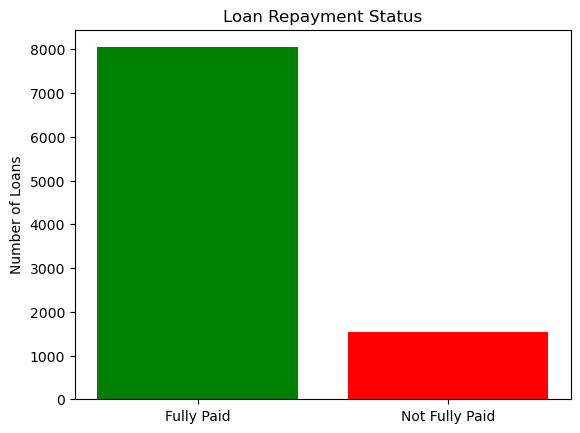

In [10]:
counts = df['not.fully.paid'].value_counts().sort_index()
colors = ['green', 'red']

plt.bar(['Fully Paid', 'Not Fully Paid'], counts, color=colors)
plt.title('Loan Repayment Status')
plt.ylabel('Number of Loans')
plt.show()

### 2.4 Correlation Between Numeric Features

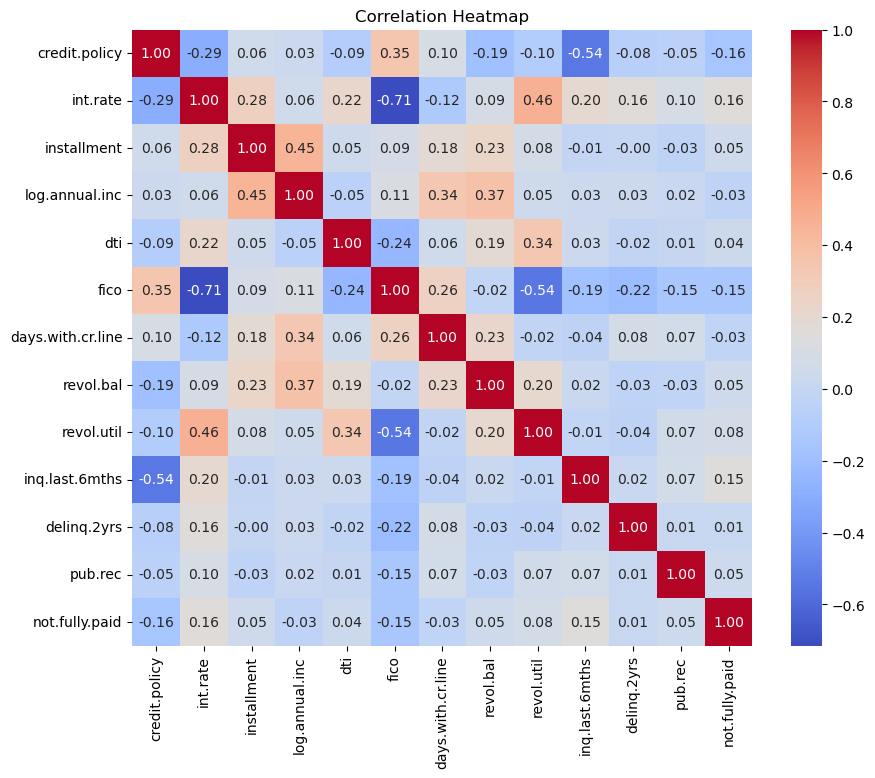

In [12]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 3. Preprocessing

The `purpose` column is categorical and must be converted to numeric form before modeling. We use one-hot encoding, which creates a separate binary column for each loan purpose category.

In [13]:
df_encoded = pd.get_dummies(df, columns=['purpose'], drop_first=True)
df_encoded.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,True,False,False,False,False,False


## 4. Train/Test Split

We split the data into training (80%) and testing (20%) sets, using stratified sampling to preserve the same class balance of `not.fully.paid` in both sets, since the target is imbalanced.

In [14]:
X = df_encoded.drop('not.fully.paid', axis=1)
y = df_encoded['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (7662, 18)
Test set shape: (1916, 18)


## 5. Model Training

Two models are trained on the same training data: **XGBoost** (a non-linear, tree-based ensemble method) and **Logistic Regression** (a linear, highly interpretable baseline). Comparing these highlights the trade-off between predictive performance and explainability, a key consideration in model risk validation.

In [15]:
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]

## 6. Model Evaluation

Since `not.fully.paid` is imbalanced (~16% positive class), accuracy alone can be misleading, a model that always predicts "fully paid" would still score ~84% accuracy while being useless for identifying risky loans. We therefore evaluate both models using precision, recall, F1-score, and ROC-AUC, which are more appropriate for imbalanced classification and better reflect the real-world cost of missing a defaulting borrower.

In [17]:
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print("Accuracy: ", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:   ", round(recall_score(y_true, y_pred), 3))
    print("F1 Score: ", round(f1_score(y_true, y_pred), 3))
    print("ROC-AUC:  ", round(roc_auc_score(y_true, y_proba), 3))
    print()
    print(confusion_matrix(y_true, y_pred))
    print()

evaluate_model("XGBoost", y_test, xgb_preds, xgb_proba)
evaluate_model("Logistic Regression", y_test, log_preds, log_proba)

--- XGBoost ---
Accuracy:  0.824
Precision: 0.313
Recall:    0.085
F1 Score:  0.133
ROC-AUC:   0.622

[[1552   57]
 [ 281   26]]

--- Logistic Regression ---
Accuracy:  0.84
Precision: 0.519
Recall:    0.046
F1 Score:  0.084
ROC-AUC:   0.683

[[1596   13]
 [ 293   14]]



In [18]:
xgb_model_balanced = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=(y_train==0).sum()/(y_train==1).sum())
xgb_model_balanced.fit(X_train, y_train)
xgb_preds_b = xgb_model_balanced.predict(X_test)
xgb_proba_b = xgb_model_balanced.predict_proba(X_test)[:, 1]

log_model_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_model_balanced.fit(X_train_scaled, y_train)
log_preds_b = log_model_balanced.predict(X_test_scaled)
log_proba_b = log_model_balanced.predict_proba(X_test_scaled)[:, 1]

evaluate_model("XGBoost (Balanced)", y_test, xgb_preds_b, xgb_proba_b)
evaluate_model("Logistic Regression (Balanced)", y_test, log_preds_b, log_proba_b)

--- XGBoost (Balanced) ---
Accuracy:  0.763
Precision: 0.235
Recall:    0.212
F1 Score:  0.223
ROC-AUC:   0.604

[[1397  212]
 [ 242   65]]

--- Logistic Regression (Balanced) ---
Accuracy:  0.64
Precision: 0.239
Recall:    0.57
F1 Score:  0.337
ROC-AUC:   0.684

[[1052  557]
 [ 132  175]]



## Part B: Adult Census Income Classification

This section applies the same two models, **XGBoost** and **Logistic Regression**, to the UCI Adult Census Income dataset, predicting whether an individual's income exceeds \$50K. This dataset represents a demographic-linked classification use case, complementing Part A's lending-risk model and allowing comparison of insights across two distinct business contexts.

## 1. Load and Inspect the Data

In [19]:
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
           'marital_status', 'occupation', 'relationship', 'race', 'sex',
           'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

adult_train = pd.read_csv('adult_train.csv', header=None, names=columns, na_values=' ?', skipinitialspace=True, skiprows=1)
adult_test = pd.read_csv('adult_test.csv', header=None, names=columns, na_values=' ?', skipinitialspace=True, skiprows=1)

print("Train shape:", adult_train.shape)
print("Test shape:", adult_test.shape)
adult_train.head()

Train shape: (32561, 15)
Test shape: (16282, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [20]:
print("Columns:", list(adult_train.columns))
adult_train.info()

Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country 

In [21]:
adult_train.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [22]:
adult_test.tail(3)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
16279,38,Private,374983.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
16280,44,Private,83891.0,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455.0,0.0,40.0,United-States,<=50K.
16281,35,Self-emp-inc,182148.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,60.0,United-States,>50K.


In [23]:
print(adult_train['income'].value_counts())
print(adult_test['income'].value_counts())

income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K.    12435
>50K.      3846
Name: count, dtype: int64


## 2. Data Cleaning

The test set's income labels contain a trailing period (e.g., `<=50K.`) that does not appear in the training labels. To keep methodology consistent with Part A, both files are combined into a single dataset, cleaned, and re-split ourselves.

In [24]:
# Fix trailing period in test labels
adult_test['income'] = adult_test['income'].str.rstrip('.')

# Combine into one dataset
adult = pd.concat([adult_train, adult_test], ignore_index=True)

print("Combined shape:", adult.shape)
print(adult['income'].value_counts())

Combined shape: (48843, 15)
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


### 2.1 Handling Missing Values

`workclass`, `occupation`, and `native_country` contain missing values (originally coded as `?`). Since these are categorical columns, missing values are filled with `"Unknown"` rather than dropped, to avoid losing data unnecessarily.

In [25]:
adult['workclass'] = adult['workclass'].fillna('Unknown')
adult['occupation'] = adult['occupation'].fillna('Unknown')
adult['native_country'] = adult['native_country'].fillna('Unknown')

print(adult.isnull().sum())

age               0
workclass         0
fnlwgt            1
education         1
education_num     1
marital_status    1
occupation        0
relationship      1
race              1
sex               1
capital_gain      1
capital_loss      1
hours_per_week    1
native_country    0
income            1
dtype: int64


## 3. Exploratory Data Analysis

### 3.1 Target Variable Balance

In [26]:
print(adult['income'].value_counts())
print(adult['income'].value_counts(normalize=True))

income
<=50K    37155
>50K     11687
Name: count, dtype: int64
income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64


### 3.2 Visualising Income Distribution

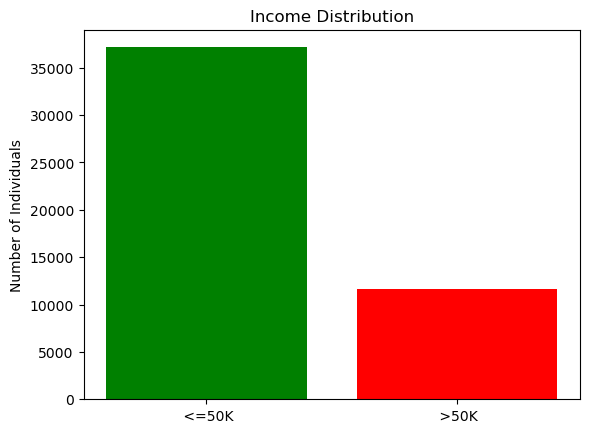

In [27]:
counts = adult['income'].value_counts()
colors = ['green', 'red']  # <=50K = green, >50K = red

plt.bar(counts.index, counts.values, color=colors)
plt.title('Income Distribution')
plt.ylabel('Number of Individuals')
plt.show()

### 3.3 Correlation Between Numeric Features

In [30]:
print("Unique income values:", adult['income'].unique())
print()
print("Age unique non-numeric check:")
non_numeric_ages = adult[~adult['age'].astype(str).str.strip().str.isdigit()]
print(non_numeric_ages[['age']].head(10))
print("Count of non-numeric age rows:", len(non_numeric_ages))

Unique income values: [' <=50K' ' >50K' nan]

Age unique non-numeric check:
                        age
32561  |1x3 Cross validator
Count of non-numeric age rows: 1


In [31]:
# Remove the known corrupted artifact row from the original UCI test file
adult = adult[adult['age'] != '|1x3 Cross validator']

# Strip whitespace from income and fix trailing periods
adult['income'] = adult['income'].astype(str).str.strip().str.rstrip('.')

# Convert age back to numeric
adult['age'] = pd.to_numeric(adult['age'])

# Drop any remaining fully-missing rows
adult = adult.dropna(subset=['income'])

print("Cleaned shape:", adult.shape)
print(adult['income'].value_counts())
print()
print("age dtype:", adult['age'].dtype)

Cleaned shape: (48842, 15)
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

age dtype: int64


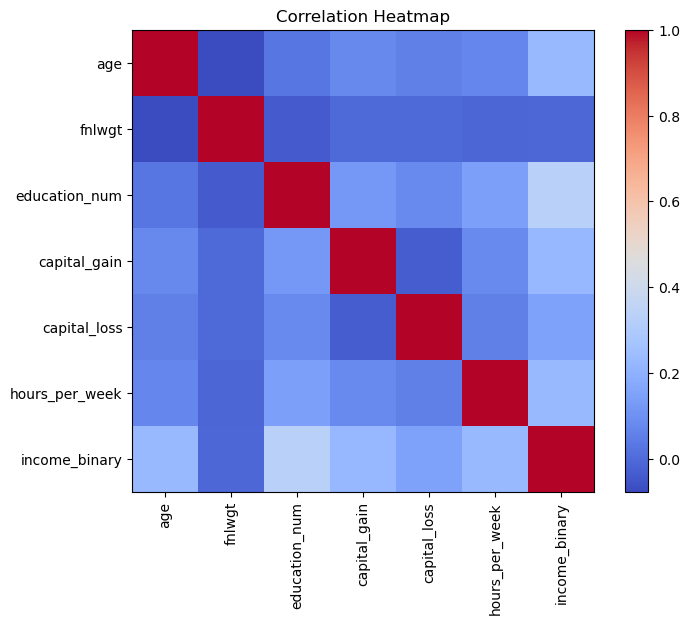

In [35]:
adult_numeric = adult.copy()
adult_numeric['income_binary'] = (adult_numeric['income'] == '>50K').astype(int)

numeric_cols = adult_numeric.select_dtypes(include=[np.number])
correlation = numeric_cols.corr()


plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('Correlation Heatmap')
plt.show()

In [33]:
correlation['income_binary'].sort_values(ascending=False)

income_binary     1.000000
education_num     0.332613
age               0.230369
hours_per_week    0.227687
capital_gain      0.223013
capital_loss      0.147554
fnlwgt           -0.006339
Name: income_binary, dtype: float64

## 4. Preprocessing

Categorical columns are one-hot encoded, and the target variable is converted to binary (1 = >50K, 0 = <=50K).

In [36]:
adult_encoded = adult.copy()
adult_encoded['income'] = (adult_encoded['income'] == '>50K').astype(int)

categorical_cols = ['workclass', 'education', 'marital_status', 'occupation',
                     'relationship', 'race', 'sex', 'native_country']
adult_encoded = pd.get_dummies(adult_encoded, columns=categorical_cols, drop_first=True)

print("Encoded shape:", adult_encoded.shape)
adult_encoded.head()

Encoded shape: (48842, 101)


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,workclass_ Without-pay,workclass_Unknown,education_ 11th,education_ 12th,education_ 1st-4th,education_ 5th-6th,education_ 7th-8th,education_ 9th,education_ Assoc-acdm,education_ Assoc-voc,education_ Bachelors,education_ Doctorate,education_ HS-grad,education_ Masters,education_ Preschool,education_ Prof-school,education_ Some-college,marital_status_ Married-AF-spouse,marital_status_ Married-civ-spouse,marital_status_ Married-spouse-absent,marital_status_ Never-married,marital_status_ Separated,marital_status_ Widowed,occupation_ Armed-Forces,occupation_ Craft-repair,occupation_ Exec-managerial,occupation_ Farming-fishing,occupation_ Handlers-cleaners,occupation_ Machine-op-inspct,occupation_ Other-service,occupation_ Priv-house-serv,occupation_ Prof-specialty,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving,occupation_Unknown,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Male,native_country_ Canada,native_country_ China,native_country_ Columbia,native_country_ Cuba,native_country_ Dominican-Republic,native_country_ Ecuador,native_country_ El-Salvador,native_country_ England,native_country_ France,native_country_ Germany,native_country_ Greece,native_country_ Guatemala,native_country_ Haiti,native_country_ Holand-Netherlands,native_country_ Honduras,native_country_ Hong,native_country_ Hungary,native_country_ India,native_country_ Iran,native_country_ Ireland,native_country_ Italy,native_country_ Jamaica,native_country_ Japan,native_country_ Laos,native_country_ Mexico,native_country_ Nicaragua,native_country_ Outlying-US(Guam-USVI-etc),native_country_ Peru,native_country_ Philippines,native_country_ Poland,native_country_ Portugal,native_country_ Puerto-Rico,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia,native_country_Unknown
0,39,77516.0,13.0,2174.0,0.0,40.0,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,50,83311.0,13.0,0.0,0.0,13.0,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,38,215646.0,9.0,0.0,0.0,40.0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

## 5. Train/Test Split

In [37]:
X2 = adult_encoded.drop('income', axis=1)
y2 = adult_encoded['income']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print("Training set shape:", X2_train.shape)
print("Test set shape:", X2_test.shape)

Training set shape: (39073, 100)
Test set shape: (9769, 100)


## 6. Model Training

In [38]:
xgb_model2 = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model2.fit(X2_train, y2_train)

xgb_preds2 = xgb_model2.predict(X2_test)
xgb_proba2 = xgb_model2.predict_proba(X2_test)[:, 1]

In [39]:
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

log_model2 = LogisticRegression(random_state=42, max_iter=1000)
log_model2.fit(X2_train_scaled, y2_train)

log_preds2 = log_model2.predict(X2_test_scaled)
log_proba2 = log_model2.predict_proba(X2_test_scaled)[:, 1]

## 7. Model Evaluation

The same evaluation approach from Part A is applied here. Since the income classes are moderately imbalanced (~76%/24%), precision, recall, F1, and ROC-AUC are again more informative than accuracy alone.

In [40]:
evaluate_model("XGBoost (Adult Census)", y2_test, xgb_preds2, xgb_proba2)
evaluate_model("Logistic Regression (Adult Census)", y2_test, log_preds2, log_proba2)

--- XGBoost (Adult Census) ---
Accuracy:  0.878
Precision: 0.79
Recall:    0.666
F1 Score:  0.722
ROC-AUC:   0.93

[[7017  414]
 [ 782 1556]]

--- Logistic Regression (Adult Census) ---
Accuracy:  0.851
Precision: 0.731
Recall:    0.6
F1 Score:  0.659
ROC-AUC:   0.905

[[6915  516]
 [ 935 1403]]



### 7.1 Class-Balanced Models

For consistency with Part A, class-weighted versions of both models are also tested here, to check whether balancing meaningfully improves recall on this comparatively less imbalanced dataset.

In [41]:
xgb_model2_balanced = XGBClassifier(
    random_state=42, eval_metric='logloss',
    scale_pos_weight=(y2_train==0).sum()/(y2_train==1).sum()
)
xgb_model2_balanced.fit(X2_train, y2_train)
xgb_preds2_b = xgb_model2_balanced.predict(X2_test)
xgb_proba2_b = xgb_model2_balanced.predict_proba(X2_test)[:, 1]

log_model2_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_model2_balanced.fit(X2_train_scaled, y2_train)
log_preds2_b = log_model2_balanced.predict(X2_test_scaled)
log_proba2_b = log_model2_balanced.predict_proba(X2_test_scaled)[:, 1]

evaluate_model("XGBoost (Adult Census, Balanced)", y2_test, xgb_preds2_b, xgb_proba2_b)
evaluate_model("Logistic Regression (Adult Census, Balanced)", y2_test, log_preds2_b, log_proba2_b)

--- XGBoost (Adult Census, Balanced) ---
Accuracy:  0.838
Precision: 0.617
Recall:    0.849
F1 Score:  0.714
ROC-AUC:   0.93

[[6199 1232]
 [ 354 1984]]

--- Logistic Regression (Adult Census, Balanced) ---
Accuracy:  0.808
Precision: 0.568
Recall:    0.831
F1 Score:  0.674
ROC-AUC:   0.905

[[5951 1480]
 [ 396 1942]]

